# Within-App Adaptation Across Contexts

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

DATA_CANDIDATES = [
    Path("../data/mhealth_apps_metrics.csv"),
    Path("./mhealth_apps_metrics.csv"),
]
metrics_results = next((p for p in DATA_CANDIDATES if p.exists()), None)
if metrics_results is None:
    raise FileNotFoundError(
        "Could not find the metrics CSV. Checked: " + ", ".join(map(str, DATA_CANDIDATES))
    )
print(f"Using dataset: {metrics_results}")

REGION_MAP = {
    "us": "North America", "ca": "North America", "gl":"North America",
    "mx": "Latin America", "br": "Latin America", "ar": "Latin America", "cl": "Latin America",
    "de": "Europe", "fr": "Europe", "gb": "Europe", "pl": "Europe",
    "tr": "Middle East", "il": "Middle East", "sa": "Middle East", "ae": "Middle East",
    "in": "Asia", "jp": "Asia", "sg": "Asia", "kr": "Asia",
    "za": "Africa", "mz": "Africa", "ng": "Africa", "ke": "Africa",
    "au": "Oceania", "nz": "Oceania", "pg": "Oceania"
}

COUNTRY_LABEL_MAP = {
    "us": "United States", "ca": "Canada", "gl":"Greenland",
    "mx": "Mexico", "br": "Brazil", "ar": "Argentina", "cl": "Chile",
    "de": "Germany", "fr": "France", "gb": "Great Britain", "pl": "Poland",
    "tr": "Turkey", "il": "Israel", "sa": "Saudi Arabia", "ae": "United Arab Emirates",
    "in": "India", "jp": "Japan", "sg": "Singapore", "kr": "South Korea",
    "za": "South Africa", "mz": "Mozambique", "ng": "Nigeria", "ke": "Kenya",
    "au": "Australia", "nz": "New Zealand", "pg": "Papua New Guinea"
}

REGION_ORDER = [
    "North America", "Latin America", "Europe",
    "Middle East", "Asia", "Africa", "Oceania"
]

region_palette = plt.cm.tab10(np.linspace(0, 1, len(REGION_ORDER)))
REGION_COLORS = {region: region_palette[i] for i, region in enumerate(REGION_ORDER)}
category_palette = plt.cm.tab20(np.linspace(0, 1, 20))


Using dataset: ../data/mhealth_apps_metrics.csv


In [11]:
import ast
from itertools import combinations

import numpy as np
import pandas as pd


def coerce_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def safe_literal_eval(value):
    if pd.isna(value):
        return None
    if isinstance(value, (list, dict, tuple, set, frozenset)):
        return value
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "no content"}:
        return None
    try:
        return ast.literal_eval(text)
    except Exception:
        return None


def parse_freq_map(value):
    parsed = safe_literal_eval(value)
    if isinstance(parsed, dict):
        return {str(k).strip().lower(): float(v) for k, v in parsed.items()}
    return {}


def parse_type_set(value):
    parsed = safe_literal_eval(value)
    if isinstance(parsed, (set, frozenset, list, tuple)):
        return {str(v).strip().lower() for v in parsed}
    return set()


def merge_frequency_maps(*maps):
    merged = {}
    for mp in maps:
        if not isinstance(mp, dict):
            continue
        for k, v in mp.items():
            merged[k] = merged.get(k, 0.0) + float(v)
    return merged


def build_country_feature_dict_from_df(country_df):
    feature_dict = {}
    for state in ["pre", "post"]:
        freq_maps = country_df.get(f"{state}_type_frequencies_map", pd.Series(dtype=object))
        merged = merge_frequency_maps(*freq_maps.tolist())
        for k, v in merged.items():
            feature_dict[f"{state}_freq::{k}"] = float(v)

        type_col = f"{state}_observed_data_types_set"
        types = set().union(*country_df[type_col].tolist()) if type_col in country_df.columns else set()
        for t in types:
            feature_dict[f"{state}_type::{t}"] = 1.0
    return feature_dict


def normalized_l1_distance(feat_a, feat_b):
    keys = set(feat_a) | set(feat_b)
    if not keys:
        return 0.0
    num = sum(abs(float(feat_a.get(k, 0.0)) - float(feat_b.get(k, 0.0))) for k in keys)
    den = sum(abs(float(feat_a.get(k, 0.0))) + abs(float(feat_b.get(k, 0.0))) for k in keys)
    return 0.0 if den == 0 else num / den


# Load and prepare dataset
df = pd.read_csv(metrics_results, low_memory=False)
print("Raw shape:", df.shape)

if "country" not in df.columns or "app_id" not in df.columns:
    raise ValueError("Dataset must contain app_id and country columns.")

df["country"] = df["country"].astype(str).str.strip().str.lower()
df["country_label"] = df["country"].map(COUNTRY_LABEL_MAP).fillna(df.get("country_label"))
df["region"] = df["country"].map(REGION_MAP).fillna(df.get("region"))

if "categories" in df.columns:
    df["category"] = df["categories"].fillna("Unknown").astype(str).str.strip()
elif "category" in df.columns:
    df["category"] = df["category"].fillna("Unknown").astype(str).str.strip()
else:
    df["category"] = "Unknown"

for col in [
    "ADII", "DGI", "PCLR", "AS",
    "num_permissions", "num_dangerous_permissions", "num_trackers",
    "downloads_int", "average_score",
]:
    if col in df.columns:
        df[col] = coerce_numeric(df[col])

for col in ["pre_type_frequencies_map", "post_type_frequencies_map"]:
    if col in df.columns:
        df[col] = df[col].map(parse_freq_map)

for col in ["pre_observed_data_types_set", "post_observed_data_types_set"]:
    if col in df.columns:
        df[col] = df[col].map(parse_type_set)

required_metrics = ["ADII", "DGI", "PCLR"]
missing_required = [c for c in required_metrics if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required metric columns: {missing_required}")

analysis_df = df.dropna(subset=["ADII", "DGI"]).copy()
analysis_df = analysis_df[analysis_df["region"].notna() & analysis_df["country_label"].notna()].copy()

as_cols = [
    "app_id", "country",
    "pre_type_frequencies_map", "post_type_frequencies_map",
    "pre_observed_data_types_set", "post_observed_data_types_set",
]
as_cols = [c for c in as_cols if c in df.columns]

features_by_app = {}
for (app_id, country), g in df[as_cols].groupby(["app_id", "country"], dropna=True, sort=False):
    features_by_app.setdefault(app_id, {})[country] = build_country_feature_dict_from_df(g)

print("Analysis shape:", analysis_df.shape)
print("Unique apps:", analysis_df["app_id"].nunique())


Raw shape: (23392, 134)
Analysis shape: (23392, 134)
Unique apps: 931


In [12]:
print("Before shape:", df.shape)
print("After shape:", analysis_df.shape)

# -----------------------------
# Unique app counts per country
# -----------------------------
country_app_counts = (
    analysis_df.groupby(["region", "country_label"])["app_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="unique_app_count")
)

# country_app_counts

Before shape: (23392, 134)
After shape: (23392, 134)


In [13]:

summary = pd.DataFrame({
    "non_null": analysis_df[["ADII", "DGI", "PCLR", "AS"]].notna().sum(),
    "mean": analysis_df[["ADII", "DGI", "PCLR", "AS"]].mean(),
    "median": analysis_df[["ADII", "DGI", "PCLR", "AS"]].median(),
    "std": analysis_df[["ADII", "DGI", "PCLR", "AS"]].std(),
    "min": analysis_df[["ADII", "DGI", "PCLR", "AS"]].min(),
    "max": analysis_df[["ADII", "DGI", "PCLR", "AS"]].max(),
}).round(4)
summary


,non_null,mean,median,std,min,max
ADII,23392,189.0859,100.0000,323.8028,7.0000,12935.0000
DGI,23392,0.2559,0.0000,0.3968,0.0000,1.0000
PCLR,11967,0.3063,0.2000,0.3386,0.0000,1.0000
AS,23383,0.3787,0.3761,0.0924,0.1064,0.7473


In [14]:
country_level = analysis_df.copy()

# Rebuild app-level metrics from the prepared analysis dataframe.
metric_agg = {"ADII": "mean", "DGI": "mean", "PCLR": "mean", "AS": "first"}
meta_agg = {
    "country_label": "nunique",
    "category": lambda s: s.dropna().mode().iat[0] if not s.dropna().mode().empty else np.nan,
    "num_permissions": "mean",
    "num_dangerous_permissions": "mean",
    "num_trackers": "mean",
    "downloads_int": "mean",
    "average_score": "mean",
}
agg_dict = {k: v for k, v in {**metric_agg, **meta_agg}.items() if k in analysis_df.columns}
app_level = analysis_df.groupby("app_id", as_index=False).agg(agg_dict)
app_level = app_level.rename(columns={"country_label": "country_count"})
app_level_all = app_level.copy()

print("Country-level rows:", len(country_level))
print("App-level rows:", len(app_level_all))
print("App-level metric columns:", [c for c in ["ADII", "DGI", "PCLR", "AS"] if c in app_level_all.columns])
app_level = app_level_all.copy()


Country-level rows: 23392
App-level rows: 931
App-level metric columns: ['ADII', 'DGI', 'PCLR', 'AS']



## Figures — Within-App Privacy Adaptation Analysis

This section analyzes cross-country within-app privacy adaptation using the app-level Adaptation Score (AS). It:
- groups apps into adaptation tiers,
- examines how adaptation relates to privacy risk and transparency,
- identifies which app categories and regions are most associated with adaptive behavior,
- highlights apps that are both adaptive and privacy-invasive.

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

MIN_COUNTRIES = 3
RANDOM_STATE = 42
N_CLUSTERS = 3

CATV = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

adaptation_order = ["Stable", "Partially adaptive", "Highly adaptive"]
group_colors = {"Stable": CATV[0], "Partially adaptive": CATV[1], "Highly adaptive": CATV[7]}

def mode_or_first(series):
    s = series.dropna()
    if s.empty:
        return np.nan
    m = s.mode()
    return m.iat[0] if not m.empty else s.iloc[0]

adaptation_app_level = (
    df.groupby("app_id", as_index=False)
    .agg(
        ADII=("ADII", "mean"),
        PCLR=("PCLR", "mean"),
        AS=("AS", "mean"),
        DGI=("DGI", "mean"),
        downloads=("downloads_int", "first"),
        n_countries=("country", "nunique"),
        category=("category", mode_or_first),
        num_trackers=("num_trackers", "median"),
        num_permissions=("num_permissions", "median"),
        num_dangerous_permissions=("num_dangerous_permissions", "median"),
        country_count=("country_label", "nunique"),
    )
    .dropna(subset=["ADII", "PCLR", "AS", "DGI"])
)
adaptation_app_level = adaptation_app_level.loc[
    adaptation_app_level["n_countries"] >= MIN_COUNTRIES
].copy()

if adaptation_app_level.empty:
    raise ValueError(f"No apps remain after filtering for n_countries >= {MIN_COUNTRIES} and complete metrics.")
if adaptation_app_level["AS"].nunique() < N_CLUSTERS:
    raise ValueError(f"AS has only {adaptation_app_level['AS'].nunique()} unique values; cannot fit {N_CLUSTERS} clusters reliably.")

print(f"Apps retained after country filtering (n_countries >= {MIN_COUNTRIES}) and complete ADII/DGI/PCLR/AS: {len(adaptation_app_level)}")
print(f"Median countries observed per app: {adaptation_app_level['n_countries'].median():.1f}")

as_scaled = StandardScaler().fit_transform(adaptation_app_level[["AS"]])

print("\nAS-regime clustering: silhouette / Calinski-Harabasz by k")
for k in range(2, 7):
    trial_labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(as_scaled)
    print(f"  k={k}: silhouette={silhouette_score(as_scaled, trial_labels):.3f}, "
          f"CH={calinski_harabasz_score(as_scaled, trial_labels):.1f}")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
adaptation_app_level["adaptation_cluster"] = kmeans.fit_predict(as_scaled)

grp_means = adaptation_app_level.groupby("adaptation_cluster")["AS"].mean().sort_values()
cluster_to_label = {
    grp_means.index[0]: "Stable",
    grp_means.index[1]: "Partially adaptive",
    grp_means.index[2]: "Highly adaptive",
}
adaptation_app_level["adaptation_group"] = adaptation_app_level["adaptation_cluster"].map(cluster_to_label)
adaptation_app_level["adaptation_group"] = pd.Categorical(
    adaptation_app_level["adaptation_group"], categories=adaptation_order, ordered=True
)

centroid_df = (
    adaptation_app_level.groupby("adaptation_group", observed=True)["AS"]
    .mean()
    .reindex(adaptation_order)
    .rename("centroid_AS")
    .reset_index()
    .rename(columns={"adaptation_group": "cluster"})
)
print("\nAS-regime centroids used for primary AS groups (k=3):")
display(centroid_df)

group_counts = (
    adaptation_app_level["adaptation_group"]
    .value_counts(dropna=False)
    .reindex(adaptation_order, fill_value=0)
    .rename_axis("adaptation_group")
    .reset_index(name="apps")
)
group_counts["percent"] = 100 * group_counts["apps"] / group_counts["apps"].sum()
print("\nPrimary adaptation groups (K-means on standardized AS):")
display(group_counts)

group_stats = (
    adaptation_app_level.groupby("adaptation_group", observed=False)
    .agg(
        apps=("app_id", "count"),
        AS_mean=("AS", "mean"),
        AS_median=("AS", "median"),
        AS_std=("AS", "std"),
        AS_min=("AS", "min"),
        AS_max=("AS", "max"),
        ADII_mean=("ADII", "mean"),
        DGI_mean=("DGI", "mean"),
        PCLR_mean=("PCLR", "mean"),
        countries_mean=("n_countries", "mean"),
        trackers_mean=("num_trackers", "mean"),
        permissions_mean=("num_permissions", "mean"),
    )
    .reindex(adaptation_order)
    .reset_index()
)
print("\nGroup descriptive statistics:")
display(group_stats.round(4))

region_by_country = analysis_df.groupby("country")["region"].first().to_dict()

retained_app_ids = set(adaptation_app_level["app_id"])
country_dev = {}
for app_id, per_country_features in features_by_app.items():
    if app_id not in retained_app_ids:
        continue
    countries = sorted(per_country_features)
    if len(countries) < MIN_COUNTRIES:
        continue
    for c in countries:
        dists = [
            normalized_l1_distance(per_country_features[c], per_country_features[c2])
            for c2 in countries if c2 != c
        ]
        if dists:
            country_dev.setdefault(c, []).append(float(np.mean(dists)))

country_deviation = pd.Series({c: np.mean(v) for c, v in country_dev.items()}).sort_values(ascending=False)
print("\nPer-country mean within-app deviation (used in Figure (c)):")
display(country_deviation.round(4))


Apps retained after country filtering (n_countries >= 3) and complete ADII/DGI/PCLR/AS: 919
Median countries observed per app: 26.0

AS-regime clustering: silhouette / Calinski-Harabasz by k
  k=2: silhouette=0.518, CH=1298.5
  k=3: silhouette=0.536, CH=1691.3
  k=4: silhouette=0.516, CH=1936.2
  k=5: silhouette=0.530, CH=2369.9
  k=6: silhouette=0.536, CH=2812.3

AS-regime centroids used for primary AS groups (k=3):


,cluster,centroid_AS
0,Stable,0.257077
1,Partially adaptive,0.375997
2,Highly adaptive,0.497372



Primary adaptation groups (K-means on standardized AS):


,adaptation_group,apps,percent
0,Stable,211,22.959739
1,Partially adaptive,481,52.339499
2,Highly adaptive,227,24.700762



Group descriptive statistics:


,adaptation_group,apps,AS_mean,AS_median,AS_std,AS_min,AS_max,ADII_mean,DGI_mean,PCLR_mean,countries_mean,trackers_mean,permissions_mean
0,Stable,211,0.2571,0.2685,0.0475,0.1064,0.3160,230.8447,0.1865,0.3376,24.9716,6.7915,23.5308
1,Partially adaptive,481,0.3760,0.3747,0.0323,0.3169,0.4359,150.6734,0.2847,0.2523,25.7131,4.6757,20.4699
2,Highly adaptive,227,0.4974,0.4828,0.0571,0.4369,0.7473,232.1775,0.2526,0.2457,25.2775,4.4053,22.9471



Per-country mean within-app deviation (used in Figure (c)):


gb    0.4131
mz    0.4073
pl    0.4070
br    0.3941
in    0.3917
mx    0.3861
sg    0.3852
nz    0.3830
kr    0.3823
tr    0.3809
sa    0.3806
gl    0.3794
ng    0.3785
jp    0.3727
cl    0.3722
ar    0.3719
za    0.3689
pg    0.3677
ca    0.3660
us    0.3653
ae    0.3651
ke    0.3627
de    0.3626
au    0.3581
fr    0.3551
il    0.3530
dtype: float64

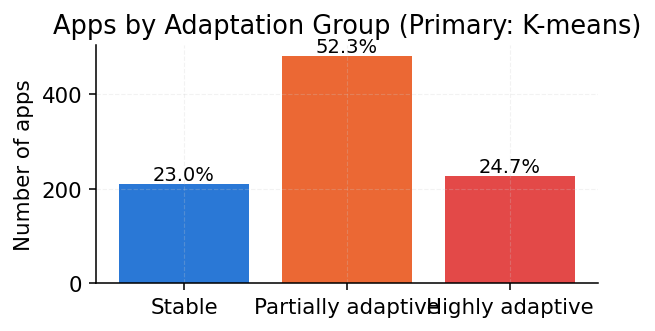

In [16]:
fig, ax = plt.subplots(figsize=(4.5, 2.5))
bars = ax.bar(
    group_counts["adaptation_group"],
    group_counts["apps"],
    color=[group_colors[g] for g in group_counts["adaptation_group"]]
)

for bar, pct in zip(bars, group_counts["percent"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Apps by Adaptation Group (Primary: K-means)")
ax.set_xlabel("")
ax.set_ylabel("Number of apps")
plt.tight_layout()
plt.savefig(FIG_DIR / "adaptation_group_counts_kmeans.png", bbox_inches="tight")
plt.show()

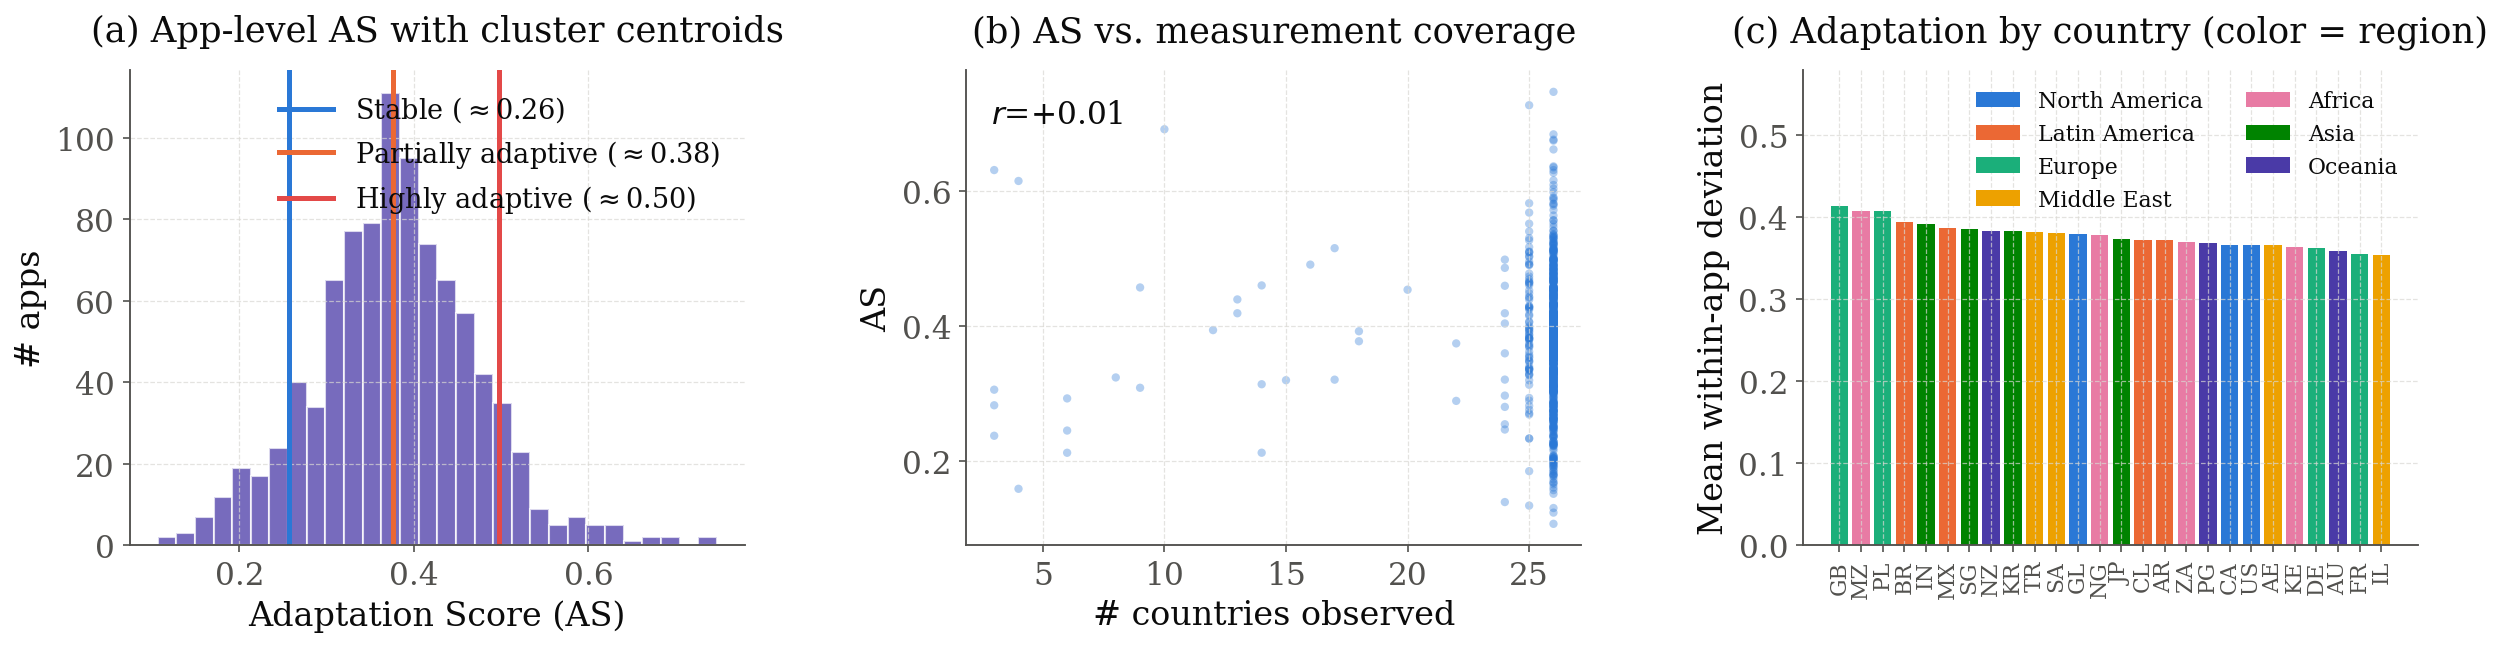

In [17]:
# -------------------------------------------------------------------
# Figure: adaptation_overview_subfigures (3-panel)
# (a) AS histogram with K-means centroids
# (b) AS vs. measurement coverage
# (c) Per-country within-app deviation, colored by region
# Matches undisclosed_scripts/13_generate_figures.py exactly.
# -------------------------------------------------------------------

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID_COLOR = "#d9d8d3"

plt.rcParams.update({
    "font.size": 16,
    "font.family": "serif",
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.edgecolor": TEXT_SECONDARY,
    "axes.labelcolor": TEXT_PRIMARY,
    "text.color": TEXT_PRIMARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.9,
    "lines.linewidth": 1.8,
    "pdf.fonttype": 42,
    "figure.dpi": 150,
})

REGION_COLORS_PANEL = {
    "North America": CATV[0], "Latin America": CATV[1], "Europe": CATV[2],
    "Middle East": CATV[3], "Africa": CATV[4], "Asia": CATV[5], "Oceania": CATV[6],
}

TITLE_PAD = 14
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))

# -----------------------------
# (a) AS histogram + k=3 cluster centroids
# -----------------------------
ax = axes[0]
as_vals = adaptation_app_level["AS"].values
ax.hist(as_vals, bins=30, color=CATV[6], alpha=0.75, edgecolor="white")
for g in adaptation_order:
    centroid = adaptation_app_level.loc[adaptation_app_level["adaptation_group"] == g, "AS"].mean()
    ax.axvline(centroid, color=group_colors[g], linewidth=2.4, label=f"{g} ($\\approx${centroid:.2f})")
ax.set_xlabel("Adaptation Score (AS)")
ax.set_ylabel("# apps")
ax.set_title("(a) App-level AS with cluster centroids", pad=TITLE_PAD)
ax.legend(frameon=False, fontsize=13, loc="upper right")

# -----------------------------
# (b) AS vs number of countries observed
# -----------------------------
ax = axes[1]
ax.scatter(adaptation_app_level["n_countries"], adaptation_app_level["AS"], s=16, alpha=0.35, color=CATV[0], edgecolors="none")
r_cov = np.corrcoef(adaptation_app_level["n_countries"], adaptation_app_level["AS"])[0, 1]
ax.text(0.04, 0.94, f"$r$={r_cov:+.2f}", transform=ax.transAxes, fontsize=15, va="top")
ax.set_xlabel("# countries observed")
ax.set_ylabel("AS")
ax.set_title("(b) AS vs. measurement coverage", pad=TITLE_PAD)

# -----------------------------
# (c) Mean within-app deviation per country, colored by region
# -----------------------------
ax = axes[2]
colors = [REGION_COLORS_PANEL.get(region_by_country.get(c), TEXT_SECONDARY) for c in country_deviation.index]
ax.bar(range(len(country_deviation)), country_deviation.values, color=colors)
ax.set_xticks(range(len(country_deviation)))
ax.set_xticklabels([c.upper() for c in country_deviation.index], rotation=90, fontsize=10.5)
ax.set_ylabel("Mean within-app deviation")
ax.set_title("(c) Adaptation by country (color = region)", pad=TITLE_PAD)
ax.set_ylim(0, country_deviation.max() * 1.4)
region_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=v) for v in REGION_COLORS_PANEL.values()]
ax.legend(region_handles, list(REGION_COLORS_PANEL.keys()), loc="upper right", frameon=False, fontsize=10.5, ncol=2)

fig.tight_layout(w_pad=3.5)
fig.savefig(FIG_DIR / "adaptation_overview_subfigures.pdf", format="pdf", bbox_inches="tight")
plt.show()


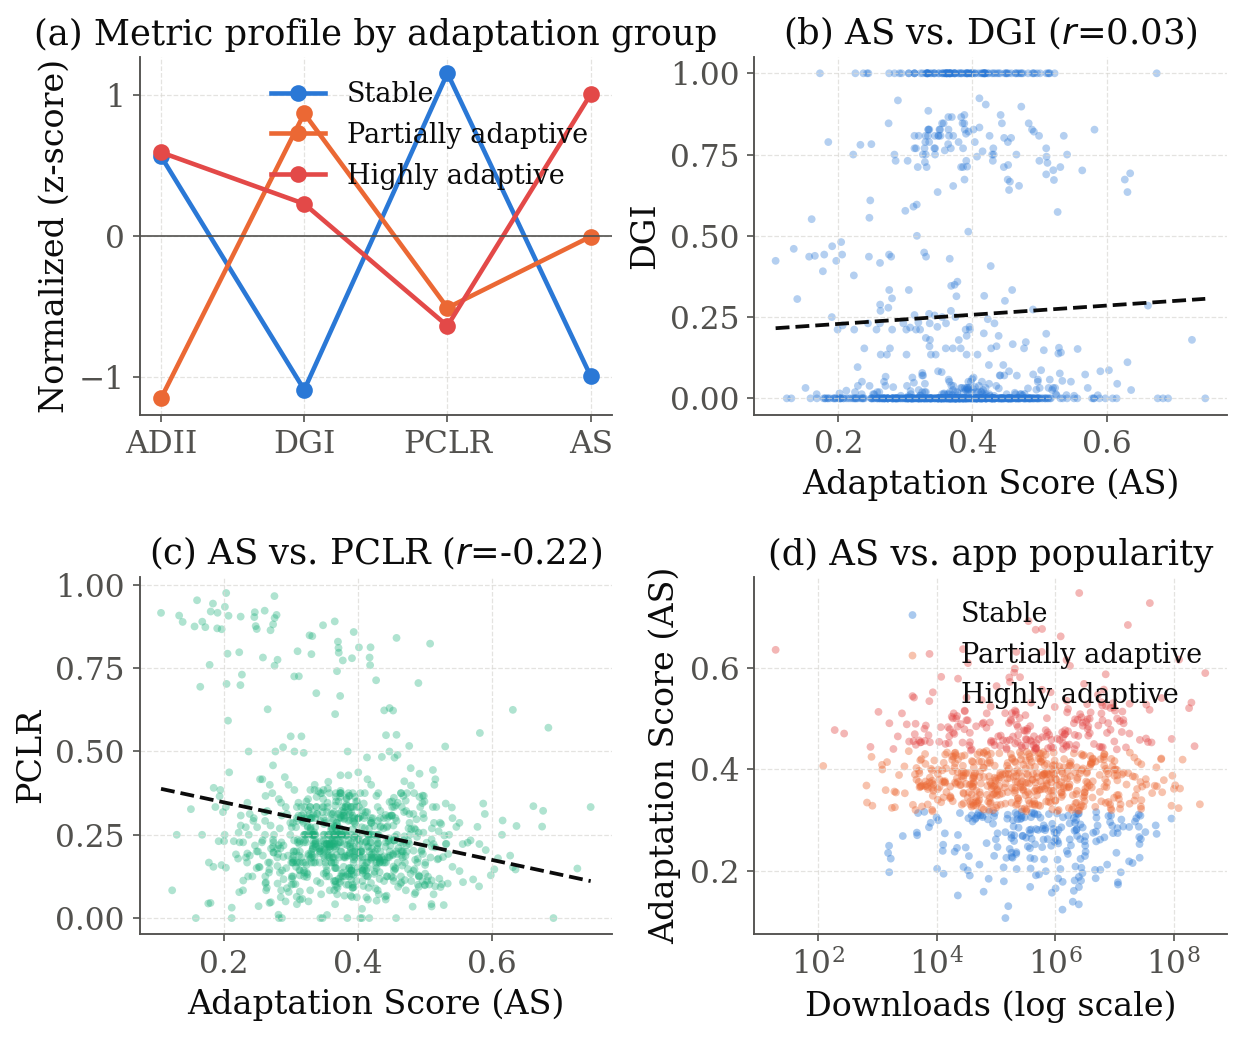

In [18]:
# -------------------------------------------------------------------
# Figure: adaptation_relationships_subfigures (4-panel)
# (a) z-scored metric profile by adaptation group
# (b) AS vs DGI
# (c) AS vs PCLR
# (d) AS vs downloads (popularity)
# Matches undisclosed_scripts/13_generate_figures.py exactly.
# -------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(8.6, 7.2))

# -----------------------------
# (a) normalized (z-scored) profiles by group
# -----------------------------
ax = axes[0, 0]
prof = adaptation_app_level.groupby("adaptation_group", observed=True)[["ADII", "DGI", "PCLR", "AS"]].mean()
prof = prof.reindex(adaptation_order)
profz = (prof - prof.mean()) / prof.std()
x = np.arange(4)
for g in adaptation_order:
    ax.plot(x, profz.loc[g], marker="o", color=group_colors[g], label=g, linewidth=2.2, markersize=7)
ax.set_xticks(x)
ax.set_xticklabels(["ADII", "DGI", "PCLR", "AS"])
ax.axhline(0, color=TEXT_SECONDARY, linewidth=0.8)
ax.set_ylabel("Normalized (z-score)")
ax.set_title("(a) Metric profile by adaptation group")
ax.legend(frameon=False, fontsize=13, loc="upper right")

# -----------------------------
# (b) AS vs DGI
# -----------------------------
ax = axes[0, 1]
ax.scatter(adaptation_app_level["AS"], adaptation_app_level["DGI"], s=14, alpha=0.35, color=CATV[0], edgecolors="none")
r = np.corrcoef(adaptation_app_level["AS"], adaptation_app_level["DGI"])[0, 1]
z = np.polyfit(adaptation_app_level["AS"], adaptation_app_level["DGI"], 1)
xs = np.linspace(adaptation_app_level["AS"].min(), adaptation_app_level["AS"].max(), 200)
ax.plot(xs, np.polyval(z, xs), color=TEXT_PRIMARY, linestyle="--", linewidth=1.8)
ax.set_xlabel("Adaptation Score (AS)")
ax.set_ylabel("DGI")
ax.set_title(f"(b) AS vs. DGI ($r$={r:.2f})")

# -----------------------------
# (c) AS vs PCLR
# -----------------------------
ax = axes[1, 0]
ax.scatter(adaptation_app_level["AS"], adaptation_app_level["PCLR"], s=14, alpha=0.35, color=CATV[2], edgecolors="none")
r2 = np.corrcoef(adaptation_app_level["AS"], adaptation_app_level["PCLR"])[0, 1]
z2 = np.polyfit(adaptation_app_level["AS"], adaptation_app_level["PCLR"], 1)
ax.plot(xs, np.polyval(z2, xs), color=TEXT_PRIMARY, linestyle="--", linewidth=1.8)
ax.set_xlabel("Adaptation Score (AS)")
ax.set_ylabel("PCLR")
ax.set_title(f"(c) AS vs. PCLR ($r$={r2:.2f})")

# -----------------------------
# (d) AS vs downloads
# -----------------------------
ax = axes[1, 1]
for g in adaptation_order:
    sub = adaptation_app_level[adaptation_app_level["adaptation_group"] == g]
    ax.scatter(sub["downloads"] + 1, sub["AS"], s=14, alpha=0.4, color=group_colors[g], label=g, edgecolors="none")
ax.set_xscale("log")
ax.set_xlabel("Downloads (log scale)")
ax.set_ylabel("Adaptation Score (AS)")
ax.set_title("(d) AS vs. app popularity")
ax.legend(frameon=False, fontsize=13, loc="upper right")

fig.tight_layout()
fig.savefig(FIG_DIR / "adaptation_relationships_subfigures.pdf", format="pdf", bbox_inches="tight")
plt.show()
